In [48]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [50]:
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

In [51]:
print(df['Potability'].value_counts())

print(df.isna().sum())

Potability
0    1998
1    1278
Name: count, dtype: int64
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [52]:
df_clean = df.fillna(df.median())

X = df_clean.drop(columns=['Potability'])
y = df_clean['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [53]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [54]:
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train, y_train)

tree_depth = dt_unpruned.get_depth()
dt_unpruned_acc_train = dt_unpruned.score(X_train, y_train)
dt_unpruned_acc_test = dt_unpruned.score(X_test, y_test)

print(f"Unpruned Tree Depth: {tree_depth}")
print(f"Unpruned Tree Accuracy (Train): {dt_unpruned_acc_train}")
print(f"Unpruned Tree Accuracy (Test): {dt_unpruned_acc_test}") 

Unpruned Tree Depth: 33
Unpruned Tree Accuracy (Train): 1.0
Unpruned Tree Accuracy (Test): 0.5808748728382502


In [55]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

The training accuracy is perfect while the test accuracy is only 58% which indicates that the model is overfitting the data. The model has very high variance and needs to be pruned. 

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

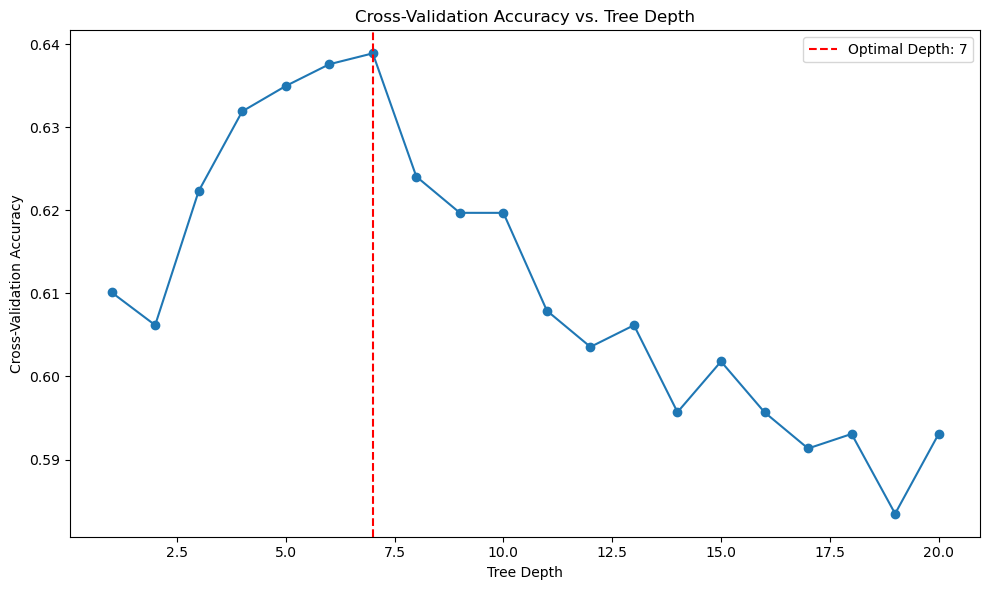

Optimal Tree Depth: 7


In [56]:
depths = range(1, 21)
cv_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_depth   = np.argmax(cv_scores) + 1

plt.figure(figsize=(10, 6))
plt.plot(depths, cv_scores, marker='o')
plt.axvline(optimal_depth, color='red', linestyle='--', label=f'Optimal Depth: {optimal_depth}')
plt.title('Cross-Validation Accuracy vs. Tree Depth')
plt.xlabel('Tree Depth')
plt.ylabel('Cross-Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal Tree Depth: {optimal_depth}")




In [57]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

It found 7 to be the optimal depth. This means the tree is allowed to split at most 7 times from the root node to any leaf. Beyond depth 7, the tree starts memorizing noise in the training data rather than learning generalizable pattern so CV accuracy stops improving and begins to decline.

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [58]:
dt_opt= DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
dt_opt.fit(X_train, y_train)

acc_dt    = dt_opt.score(X_test, y_test)

print(f"Optimized Decision Tree Accuracy (Test): {acc_dt}")



Optimized Decision Tree Accuracy (Test): 0.6459816887080366


In [59]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

It improved slightly because of the pruning of the tree to a max depth of 7. This prevented the model from memorizing noise in the training data and instead learn more general patterns hence the increase in test accuracy. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

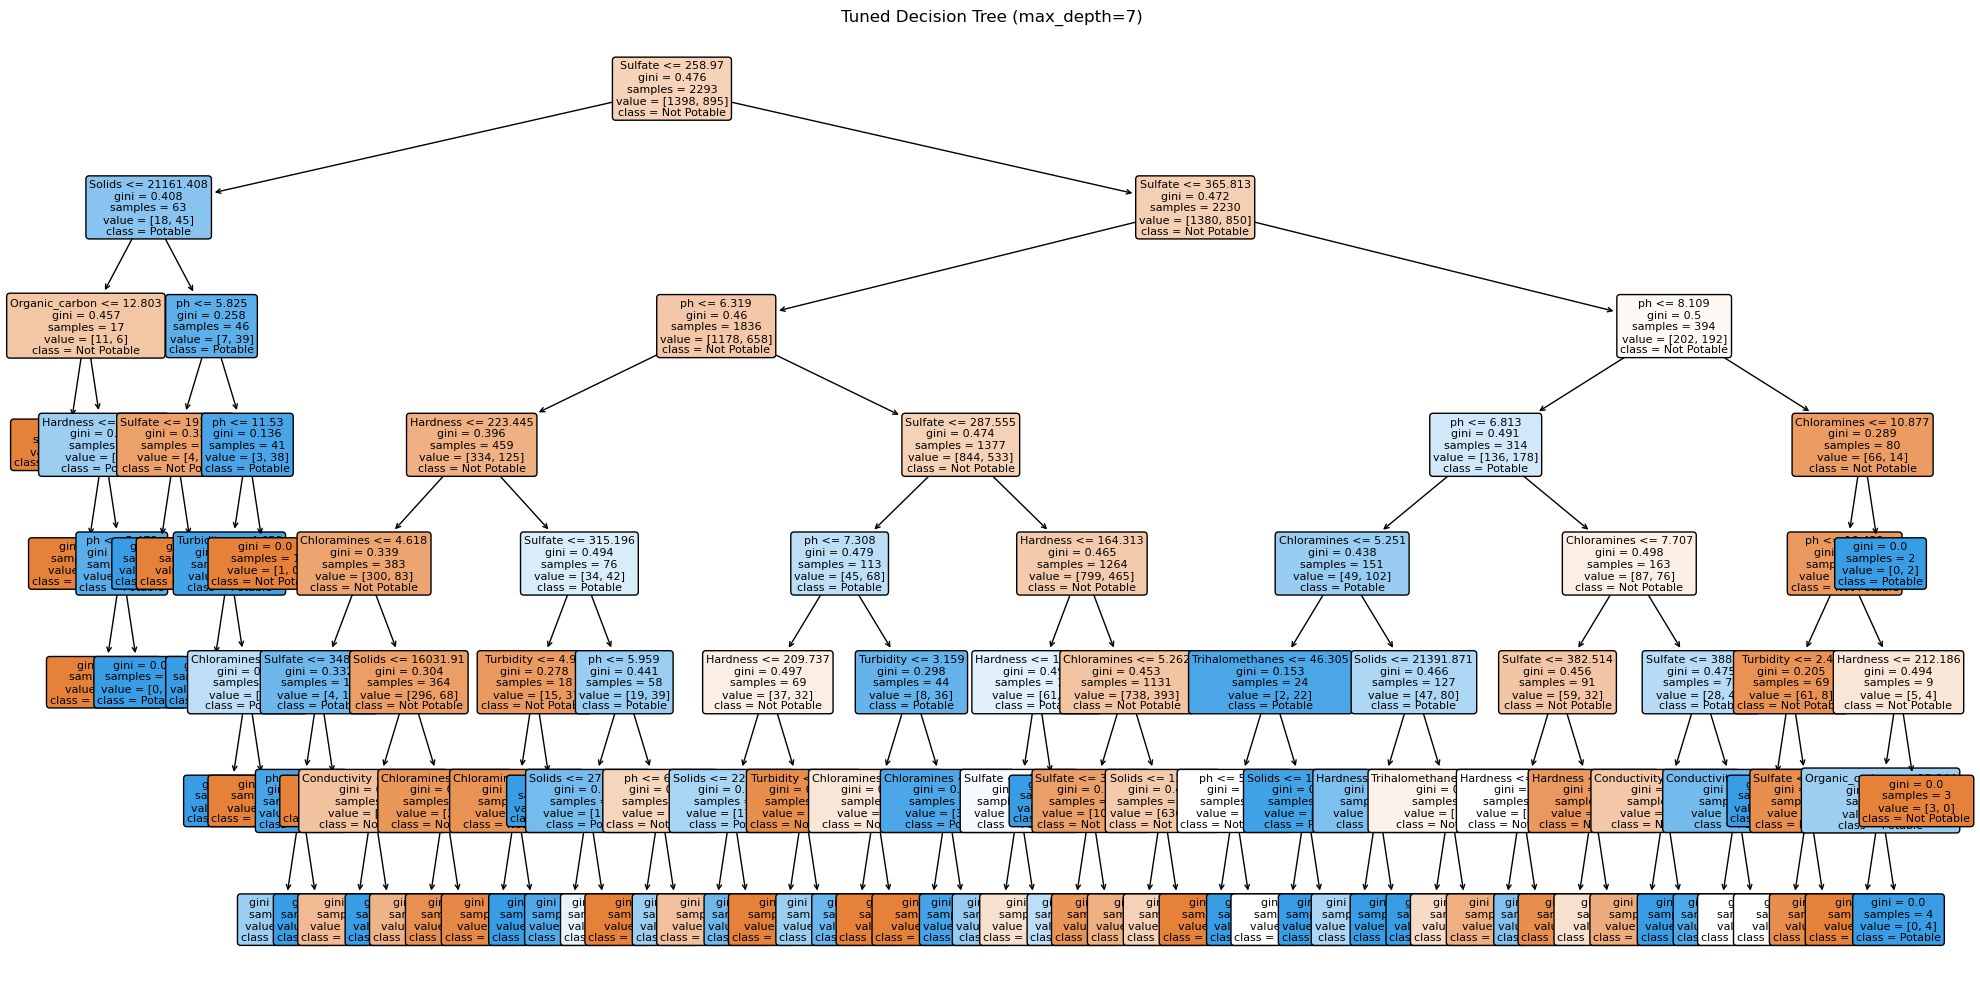

In [60]:
plt.figure(figsize=(20, 10))
plot_tree(dt_opt, feature_names=X.columns, class_names=['Not Potable', 'Potable'], 
          filled=True, rounded=True, fontsize=8)
plt.title('Tuned Decision Tree (max_depth=7)')
plt.tight_layout()
plt.savefig('tuned_tree.png', dpi=150, bbox_inches='tight')
plt.show()

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

The root splits on Sulfate, indicating it is the most discriminative feature for predicting potability. The Gini impurity drops only modestly after the first split, suggesting sulfate alone cannot cleanly separate the classes. The second level continues splitting on Sulfate and Solids, confirming these two features carry the most predictive signal in the tree.

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [61]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

acc_rf = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest Accuracy: {acc_rf:.4f}")




Random Forest Accuracy: 0.6643


In [62]:
grader.check("q5")

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError

<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

The random forest outperformed the tuned decision tree. By averaging predictions across 200 trees each trained on a random sample with a random subset of features, the random forest reduces the variance that makes a single tree sensitive to noise in the training data.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

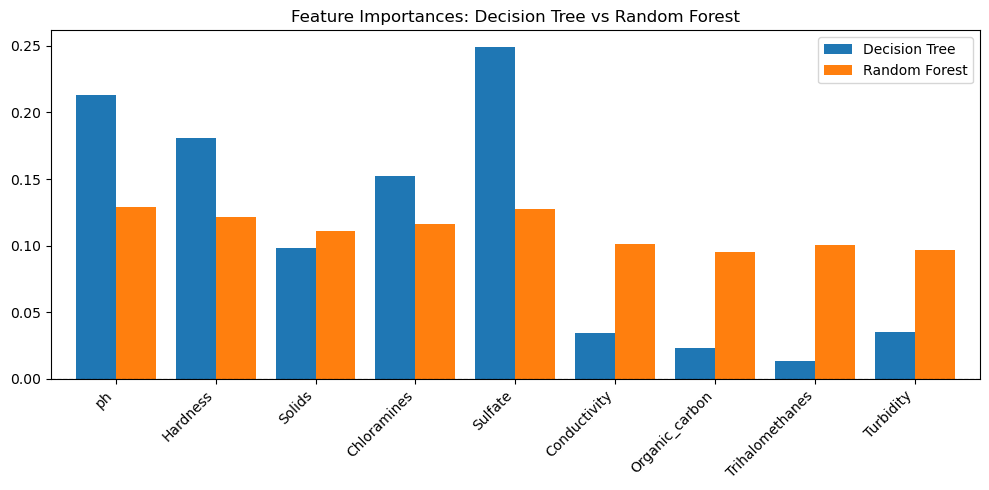

In [63]:
importances = pd.DataFrame({
    'Decision Tree': dt_opt.feature_importances_,
    'Random Forest': rf.feature_importances_
}, index=X.columns)

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot.bar(ax=ax, width=0.8)
ax.set_title('Feature Importances: Decision Tree vs Random Forest')
ax.set_xticklabels(importances.index, rotation=45, ha='right')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()


> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

The two models disagree considerably. The decision tree concentrates importance on Sulfate, pH, Hardness, and Chloramines while almost ignoring Conductivity, Organic Carbon, Trihalomethanes, and Turbidity. The random forest spreads importance much more evenly across all features. This is because a single tree is forced to commit to specific splits and can over-rely on a few features, whereas the random forest averages across many trees with randomized feature subsets, producing more reliable importance estimates. Sulfate appears most important overall, which makes physical sense as sulfate levels directly affect water safety and taste.

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

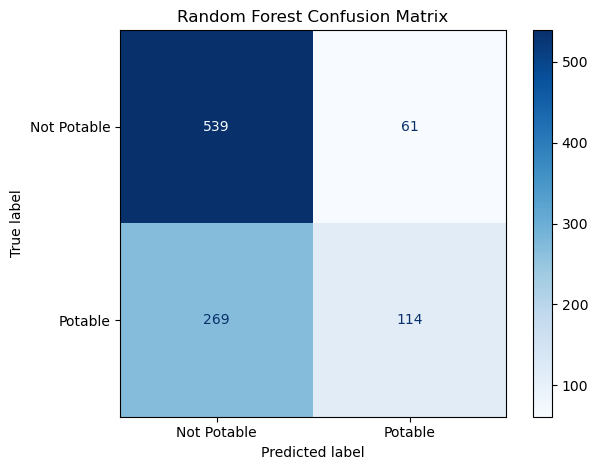

In [64]:
cm = confusion_matrix(y_test, rf.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Potable', 'Potable'])
disp.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

TP = 114
FP = 61
TN = 529
FN = 269

The model is much better at identifying non-potable water than potable water, struggling most with false negatives flagging safe water as unsafe. The false positives are the most concerning result, as they represent unsafe water being cleared as drinkable, a serious public health risk.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [65]:
model_comparison = pd.DataFrame({
    "Model": ["Unpruned Decision Tree", "Tuned Decision Tree", "Random Forest"],
    "Test Accuracy": [dt_unpruned_acc_test, acc_dt, acc_rf]
})
print(model_comparison)


                    Model  Test Accuracy
0  Unpruned Decision Tree       0.580875
1     Tuned Decision Tree       0.645982
2           Random Forest       0.664293


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


The random forest achieved the highest test accuracy, followed by the tuned decision tree, with the unpruned tree performing worst. Pruning improved accuracy meaningfully over the unpruned tree demonstrating that the fully grown tree was severely overfitting. The random forest improved further by averaging across many trees, reducing the variance that even a pruned single tree still carries.

---

Run the cell below to receive credit for autograded questions. 

In [66]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError